# Feature Representation Experiment: Mel Spectrogram + 2D CNN

Fine-tunes an ImageNet-pretrained **ResNet18** on Mel spectrograms of PSG-Audio segments for binary sleep apnea detection. Across the audio-feature-representation experiments in this project, this is the **headline backbone result** — it produced the best test-set metrics of all the backbones we evaluated.

## Objectives
- Load and preprocess PSG-Audio segments
- Perform a subject-wise stratified train/val/test split (no subject leakage; balanced apnea ratios)
- Precompute Mel spectrograms once and stream them from disk during training
- Fine-tune a 2D CNN end-to-end for binary apnea vs non-apnea classification
- Evaluate with accuracy, macro F1, confusion matrix, and per apnea-type recall
- Persist the best checkpoint, training curves, and a results JSON

## Companion notebooks (same data, splits, and loss; only the backbone changes)
- [`mel_pann.ipynb`](../Mel/mel_pann.ipynb) — AudioSet-pretrained PANN Cnn14 (the audio-pretrained alternative)
- [`mel_ast.ipynb`](../Mel/mel_ast.ipynb) — AudioSet-pretrained AST transformer (abandoned: didn't fit on the laptop GPU)
- [`raw_waveform_1dcnn.ipynb`](../Raw_waveform_1dcnn/raw_waveform_1dcnn.ipynb) — no feature engineering, small 1D CNN trained from scratch

The configuration in this notebook is the **v4 (final)** version. Section 10 (Findings) tracks the version history of how it was reached and which changes moved the metrics.

## Experiment summary

A high-level snapshot of the **v4 (final) recipe** — full justifications appear in the relevant sections below. Section 10 (Findings) discusses how this configuration was reached and how it compares against the other backbones.

| Component | Choice |
|---|---|
| **Input** | 10-second 16 kHz audio segments (160,000 samples) |
| **Feature** | Log-Mel spectrogram, **n_mels=128**, n_fft=1024, hop=512, f_min=20, f_max=8000 |
| **Normalization** | Fixed dB window mapped linearly to [0, 1]; preserves cross-segment loudness |
| **Precomputation** | Computed once on GPU via torchaudio, saved to disk as float16 (~8 GB cache) |
| **Backbone** | ResNet18, ImageNet-pretrained; conv1 adapted from 3-channel to 1-channel by averaging |
| **Input adapter** | `BatchNorm2d(1)` before the encoder — adapts dB scale to ImageNet-trained distribution |
| **Classifier head** | `Dropout(0.6)` + `Linear(512, 2)` |
| **Loss** | Focal loss (γ=2.0) with class-weighted α |
| **Optimizer** | AdamW, LR=1e-4, weight decay=1e-3 |
| **Scheduler** | `ReduceLROnPlateau` on val macro-F1, patience=2, factor=0.5 |
| **Augmentation** | SpecAugment on GPU (2 masks per batch, freq=32 of 128, time=40 frames) |
| **Regularization** | Dropout 0.6 in head, gradient clipping (max norm 1.0) |
| **Subject-wise split** | Stratified by per-subject apnea fraction (quartiles); 70/15/15, seed=42 |
| **Class imbalance** | Focal-loss α weights computed from training split only |
| **Schedule** | Up to 15 epochs, early stop after 5 stagnant epochs on val macro-F1 |
| **Selection** | Best-by-val-F1 checkpoint reloaded for test evaluation |
| **Trainable parameters** | ~11.17M (ResNet18 + adapter + head) |

## 1. Setup

Imports, device selection, and reproducibility seeds.

In [1]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import OrderedDict
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models
import torchaudio

# Shared Dataset classes (importable so DataLoader workers can pickle them)
from audio_datasets import MelSpectrogramDataset

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU


## 2. Configuration

Paths, audio/feature parameters, and training hyperparameters. All knobs you'd want to change between runs live in the next cell.

In [3]:
# === Dataset ===
DATASET_ROOT = Path(r"C:\Users\arshi\Desktop\AIS\Sem-2\Intelligent Sensing Systems\Practise Module\Project\Dataset\Audio Dataset")
PSG_DIR      = DATASET_ROOT / "PSG-AUDIO" / "APNEA_EDF"
AP_TYPES_DIR = DATASET_ROOT / "APNEA_types"

# === Precomputed features ===
# v4 because n_mels doubled (64 → 128). Older caches preserved on disk.
PRECOMPUTED_DIR = DATASET_ROOT / "PSG-AUDIO" / "PRECOMPUTED" / "mel_v4"

# === Artifact output ===
# Notebook lives at experiments/notebooks/audio/feature_representation/Mel/,
# so parents[4] climbs back to the project root.
PROJECT_ROOT     = Path.cwd().resolve().parents[4]
ARTIFACT_DIR     = PROJECT_ROOT / "experiments" / "artifacts" / "audio" / "feature_representation" / "mel_cnn"
CHECKPOINT_DIR   = ARTIFACT_DIR / "checkpoints"
RESULTS_DIR      = ARTIFACT_DIR / "results"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# === Audio ===
# Sample rate confirmed 16 kHz (resampled from 48 kHz Mic channel, 10s segments).
SAMPLE_RATE  = 16000

# === Apnea type mapping ===
APNEA_TYPE_NAMES = {0: "non-apnea", 1: "OSA", 2: "CSA", 3: "Mixed/Hypopnea", 4: "Other"}

# === Mel spectrogram params (used at precompute time) ===
# v4: n_mels back up to 128 to give OSA-discriminative high-frequency cues
# more bins. f_max stays at Nyquist (8000) per v3's lesson.
N_MELS          = 128
N_FFT           = 1024
HOP_LENGTH      = 512
TOP_DB          = 80
F_MIN           = 20
F_MAX           = 8000
PRECOMPUTE_BATCH = 64

# === SpecAugment (training only, applied on GPU per batch) ===
# FREQ_MASK_PARAM scaled with N_MELS (16/64 → 32/128) so effective masking
# stays at ~25% of bands. v1-style intensity (n_masks=2, time_mask=40).
FREQ_MASK_PARAM = 32
TIME_MASK_PARAM = 40
N_SPEC_MASKS    = 2

# === DataLoader ===
BATCH_SIZE   = 128
NUM_WORKERS  = 4        # set 0 if Windows + notebook still has pickling issues
MEL_CACHE_SIZE = 16     # per-worker LRU cache of subject arrays

# === Loss ===
# Focal loss replaces weighted CE: FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t).
# alpha handles class imbalance (same role as CE weights); gamma down-weights
# easy examples so the model focuses on hard ones — OSA lives in the hard tail.
FOCAL_GAMMA          = 2.0

# === Training ===
SEED                 = 42
NUM_EPOCHS           = 15
LEARNING_RATE        = 1e-4
WEIGHT_DECAY         = 1e-3
DROPOUT              = 0.6
GRAD_CLIP            = 1.0
EARLY_STOP_PATIENCE  = 5
LR_SCHED_PATIENCE    = 2
NUM_CLASSES          = 2
CLASS_NAMES          = ["non-apnea", "apnea"]

# === Reproducibility ===
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
# cudnn.benchmark picks the fastest algo for each input size; gives a speed
# boost at the cost of slight non-determinism across runs.
torch.backends.cudnn.benchmark = True

print("Artifact dir:", ARTIFACT_DIR)
print("Precomputed dir:", PRECOMPUTED_DIR)
print("PSG dir exists:", PSG_DIR.exists())

Artifact dir: C:\Users\arshi\Desktop\AIS\Sem-2\Intelligent Sensing Systems\Practise Module\Project\ApneaSense\experiments\artifacts\audio\feature_representation\mel_cnn
Precomputed dir: C:\Users\arshi\Desktop\AIS\Sem-2\Intelligent Sensing Systems\Practise Module\Project\Dataset\Audio Dataset\PSG-AUDIO\PRECOMPUTED\mel_v4
PSG dir exists: True


## 3. Data preparation

### 3.1 Build records DataFrame

Builds a flat DataFrame where each row is one audio segment with columns:
- `subject_id` — patient ID
- `segment_idx` — index within the subject's npy array
- `label` — 0 = non-apnea, 1 = apnea
- `apnea_type` — 0 for non-apnea; 1/2/3/4 for apnea type
- `file_type` — `ap` or `nap`

In [4]:
def build_records(psg_dir, ap_types_dir):
    """Build a DataFrame of (subject_id, segment_idx, label, apnea_type, file_type)
    without loading the full audio arrays into memory. Uses mmap_mode='r' so
    only the npy header is read to get shape.

    Subjects with no nap.npy contribute apnea segments only — handled via the
    file-existence check below, so no hardcoded subject list is needed.
    """
    records = []
    subjects = sorted(os.listdir(psg_dir))

    for subj in subjects:
        subj_path   = psg_dir / subj
        ap_file     = subj_path / f"{subj}_ap.npy"
        nap_file    = subj_path / f"{subj}_nap.npy"
        types_file  = ap_types_dir / f"{subj}_ap_types.npy"

        # Apnea segments
        if ap_file.exists():
            ap_types = np.load(types_file, allow_pickle=False) if types_file.exists() else None
            ap_mm = np.load(ap_file, mmap_mode="r")   # header only, no payload read
            n_ap = ap_mm.shape[0]
            del ap_mm

            for i in range(n_ap):
                records.append({
                    "subject_id"  : subj,
                    "segment_idx" : i,
                    "label"       : 1,
                    "apnea_type"  : int(ap_types[i]) if ap_types is not None else -1,
                    "file_type"   : "ap",
                })

        # Non-apnea segments — silently skipped if file is missing
        if not nap_file.exists():
            continue

        nap_mm = np.load(nap_file, mmap_mode="r")
        n_nap = nap_mm.shape[0]
        del nap_mm

        for i in range(n_nap):
            records.append({
                "subject_id"  : subj,
                "segment_idx" : i,
                "label"       : 0,
                "apnea_type"  : 0,
                "file_type"   : "nap",
            })

    return pd.DataFrame(records)


df = build_records(PSG_DIR, AP_TYPES_DIR)
print("Total records:", len(df))
print("Class distribution:")
print(df["label"].value_counts())
df.head()

Total records: 103210
Class distribution:
label
1    64585
0    38625
Name: count, dtype: int64


,subject_id,segment_idx,label,apnea_type,file_type
0,00000995-100507,0,1,1,ap
1,00000995-100507,1,1,1,ap
2,00000995-100507,2,1,1,ap
3,00000995-100507,3,1,1,ap
4,00000995-100507,4,1,1,ap


### 3.2 Subject-wise stratified split

Subjects are bucketed into quartiles by per-subject apnea fraction, then split within each bucket. This keeps the apnea ratio close to the dataset average across train/val/test, while preserving zero subject overlap.

In [5]:
def create_subjectwise_splits(df, subject_col="subject_id", train_size=0.70, val_size=0.15, test_size=0.15, random_state=42, n_strata=4):
    """Subject-wise split, stratified by per-subject apnea fraction.

    EDA showed 76 subjects have very different ap vs nap counts (some 600 ap
    vs 67 nap). A pure random subject split therefore drifts the apnea ratio
    by several percentage points across train/val/test. Here we group subjects
    into quartiles by apnea fraction, then split within each stratum, so the
    overall apnea ratio is preserved within ~1 pp across splits.
    """
    assert abs(train_size + val_size + test_size - 1.0) < 1e-8, "Splits must sum to 1.0"

    # Compute per-subject apnea fraction
    per_subj = (
        df.groupby(subject_col)["label"]
          .agg(["sum", "count"])
          .rename(columns={"sum": "n_apnea", "count": "n_total"})
    )
    per_subj["ap_frac"] = per_subj["n_apnea"] / per_subj["n_total"]

    # Quantile-bin into n_strata buckets. duplicates='drop' handles the edge
    # case where a stratum boundary collapses (e.g., all subjects with frac=1.0).
    per_subj["stratum"] = pd.qcut(
        per_subj["ap_frac"], q=n_strata, labels=False, duplicates="drop"
    )

    train_subj, val_subj, test_subj = [], [], []
    val_ratio_of_temp = val_size / (val_size + test_size)

    for stratum, group in per_subj.groupby("stratum"):
        subjects = sorted(group.index.tolist())
        if len(subjects) < 3:
            # Too few subjects to split — drop them all into train.
            train_subj.extend(subjects)
            continue
        tr, temp = train_test_split(subjects, test_size=(1 - train_size), random_state=random_state, shuffle=True)
        if len(temp) < 2:
            train_subj.extend(tr)
            val_subj.extend(temp)
            continue
        va, te = train_test_split(temp, test_size=(1 - val_ratio_of_temp), random_state=random_state, shuffle=True)
        train_subj.extend(tr); val_subj.extend(va); test_subj.extend(te)

    train_df = df[df[subject_col].isin(train_subj)].reset_index(drop=True)
    val_df   = df[df[subject_col].isin(val_subj)].reset_index(drop=True)
    test_df  = df[df[subject_col].isin(test_subj)].reset_index(drop=True)

    return train_df, val_df, test_df, train_subj, val_subj, test_subj


def verify_splits(train_df, val_df, test_df, subject_col="subject_id"):
    train_s = set(train_df[subject_col].unique())
    val_s   = set(val_df[subject_col].unique())
    test_s  = set(test_df[subject_col].unique())

    print(f"Train: {len(train_s)} subjects, {len(train_df)} samples")
    print(f"Val  : {len(val_s)} subjects, {len(val_df)} samples")
    print(f"Test : {len(test_s)} subjects, {len(test_df)} samples")
    print(f"Train ∩ Val : {len(train_s & val_s)} | Train ∩ Test: {len(train_s & test_s)} | Val ∩ Test: {len(val_s & test_s)}")


train_df, val_df, test_df, train_subjects, val_subjects, test_subjects = create_subjectwise_splits(df)
verify_splits(train_df, val_df, test_df)

Train: 133 subjects, 70430 samples
Val  : 29 subjects, 14822 samples
Test : 30 subjects, 17958 samples
Train ∩ Val : 0 | Train ∩ Test: 0 | Val ∩ Test: 0


In [6]:
def split_balance_report(name, split_df):
    total = len(split_df)
    n_apnea = int((split_df['label'] == 1).sum())
    n_non   = int((split_df['label'] == 0).sum())
    pct_apnea = n_apnea / total if total > 0 else 0.0
    print(f"{name:5s} | {total:6d} samples | apnea: {n_apnea:5d} ({pct_apnea:.1%}) | non-apnea: {n_non:5d} ({1-pct_apnea:.1%})")

print("=== Split class balance ===")
split_balance_report('Train', train_df)
split_balance_report('Val',   val_df)
split_balance_report('Test',  test_df)

# Flag if any split is wildly off from the overall ratio
overall_ratio = (df['label'] == 1).mean()
print(f"\nOverall apnea ratio: {overall_ratio:.1%}")
for name, sdf in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    ratio = (sdf['label'] == 1).mean()
    if abs(ratio - overall_ratio) > 0.10:
        print(f"  WARNING: {name} apnea ratio {ratio:.1%} differs from overall by >10 pp")

# Save split subjects for reproducibility across experiments
split_info = {
    "train_subjects": sorted(train_subjects),
    "val_subjects"  : sorted(val_subjects),
    "test_subjects" : sorted(test_subjects),
}
with open(RESULTS_DIR / "split_subjects.json", "w") as f:
    json.dump(split_info, f, indent=2)
print(f"\nSplit subjects saved to: {RESULTS_DIR / 'split_subjects.json'}")

=== Split class balance ===
Train |  70430 samples | apnea: 43572 (61.9%) | non-apnea: 26858 (38.1%)
Val   |  14822 samples | apnea:  9200 (62.1%) | non-apnea:  5622 (37.9%)
Test  |  17958 samples | apnea: 11813 (65.8%) | non-apnea:  6145 (34.2%)

Overall apnea ratio: 62.6%

Split subjects saved to: C:\Users\arshi\Desktop\AIS\Sem-2\Intelligent Sensing Systems\Practise Module\Project\ApneaSense\experiments\artifacts\audio\feature_representation\mel_cnn\results\split_subjects.json


### 3.3 Class weights for focal loss

Weights are computed from the **training split only** so that no test/val statistics leak into training. The values are used as the `α` term in focal loss (Section 7.1) — they handle class imbalance, while the focal `(1 − pₜ)^γ` factor handles hard-example focusing.

In [7]:
def compute_class_weights(train_df, label_col="label", num_classes=2):
    counts = train_df[label_col].value_counts().sort_index()
    total  = len(train_df)
    weights = [total / (num_classes * counts[c]) for c in range(num_classes)]
    weights = torch.tensor(weights, dtype=torch.float32)
    print("Class counts (train):", counts.to_dict())
    print("Class weights:", weights.tolist())
    return weights


class_weights = compute_class_weights(train_df)

Class counts (train): {0: 26858, 1: 43572}
Class weights: [1.3111549615859985, 0.8082025051116943]


## 4. Feature precomputation

Computes Mel spectrograms for all segments using **torchaudio on GPU** and saves to disk as float16 `.npy` files. This runs once — subsequent runs skip subjects whose precomputed files already exist. Training then loads precomputed tensors instead of recomputing the feature on every sample every epoch.

In [8]:
PRECOMPUTED_DIR.mkdir(parents=True, exist_ok=True)

mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH,
    n_mels=N_MELS, f_min=F_MIN, f_max=F_MAX,
).to(device)

# Absolute power-to-dB range used for normalization. The v1 approach
# (per-sample min-max + torchaudio AmplitudeToDB(top_db=80)) clipped each
# sample relative to its own max, which destroyed cross-segment loudness
# differences flagged as discriminative in the EDA. Using a fixed dB window
# preserves those differences. Bounds chosen empirically for PCM audio
# normalized to ~[-0.15, 0.15]: power floor ~1e-10 → -100 dB, peak ~0 dB.
DB_FLOOR = -100.0
DB_CEIL  = 0.0

subjects = sorted(os.listdir(PSG_DIR))
skipped, computed = 0, 0

for subj_idx, subj in enumerate(subjects):
    subj_path = PSG_DIR / subj

    for file_type in ['ap', 'nap']:
        src = subj_path / f'{subj}_{file_type}.npy'
        dst = PRECOMPUTED_DIR / subj / f'{subj}_{file_type}_mel.npy'

        if dst.exists():
            skipped += 1
            continue
        if not src.exists():
            continue

        data = np.load(src, allow_pickle=False).astype(np.float32)
        all_mels = []

        for i in range(0, len(data), PRECOMPUTE_BATCH):
            # from_numpy avoids the implicit copy that torch.tensor() does.
            batch = torch.from_numpy(data[i:i+PRECOMPUTE_BATCH]).to(device, non_blocking=True)
            with torch.no_grad():
                mel = mel_transform(batch)
                # Absolute power-to-dB with fixed reference of 1.0 (no
                # per-sample/per-batch max), then linear shift to [0, 1].
                mel_db = 10.0 * torch.log10(mel.clamp(min=1e-10))
                mel_db = mel_db.clamp(min=DB_FLOOR, max=DB_CEIL)
                mel_norm = (mel_db - DB_FLOOR) / (DB_CEIL - DB_FLOOR)

            all_mels.append(mel_norm.cpu().half().numpy())

        result = np.concatenate(all_mels, axis=0)
        dst.parent.mkdir(parents=True, exist_ok=True)
        np.save(dst, result)
        computed += 1

    if (subj_idx + 1) % 20 == 0:
        print(f'  {subj_idx+1}/{len(subjects)} subjects processed...')

print(f'Done! Computed: {computed} files | Skipped (already exist): {skipped}')
print(f'Saved to: {PRECOMPUTED_DIR}')

  20/192 subjects processed...
  40/192 subjects processed...
  60/192 subjects processed...
  80/192 subjects processed...
  100/192 subjects processed...
  120/192 subjects processed...
  140/192 subjects processed...
  160/192 subjects processed...
  180/192 subjects processed...
Done! Computed: 383 files | Skipped (already exist): 0
Saved to: C:\Users\arshi\Desktop\AIS\Sem-2\Intelligent Sensing Systems\Practise Module\Project\Dataset\Audio Dataset\PSG-AUDIO\PRECOMPUTED\mel_v4


## 5. Datasets and DataLoaders

The `MelSpectrogramDataset` class lives in `audio_datasets.py` (imported in Section 1). Defining it in a `.py` file is what allows PyTorch DataLoader workers to pickle the class on Windows + Jupyter — classes defined directly in notebook cells cannot be spawned across worker processes.

In [9]:
train_dataset = MelSpectrogramDataset(train_df, PRECOMPUTED_DIR, max_cache=MEL_CACHE_SIZE)
val_dataset   = MelSpectrogramDataset(val_df,   PRECOMPUTED_DIR, max_cache=MEL_CACHE_SIZE)
test_dataset  = MelSpectrogramDataset(test_df,  PRECOMPUTED_DIR, max_cache=MEL_CACHE_SIZE)

pin = torch.cuda.is_available()
persist = NUM_WORKERS > 0
g = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=pin,
    persistent_workers=persist, generator=g,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=pin, persistent_workers=persist,
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=pin, persistent_workers=persist,
)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 70430 | Val: 14822 | Test: 17958


Batch spectrogram shape: torch.Size([128, 1, 128, 313])
Batch labels: [1, 1, 1, 0, 1, 1, 1, 0, 1, 1]


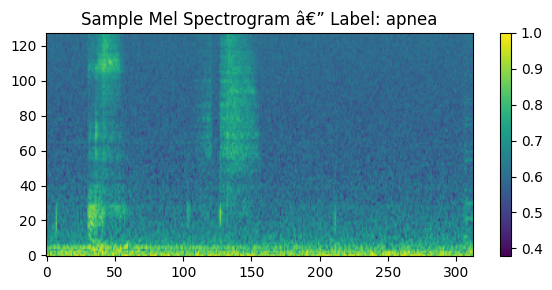

In [10]:
# Sanity check â€” inspect one batch
specs, labels = next(iter(train_loader))
print("Batch spectrogram shape:", specs.shape)
print("Batch labels:", labels[:10].tolist())

plt.figure(figsize=(6, 3))
plt.imshow(specs[0].squeeze().numpy(), aspect="auto", origin="lower")
plt.title(f"Sample Mel Spectrogram â€” Label: {CLASS_NAMES[labels[0]]}")
plt.colorbar()
plt.tight_layout()
plt.show()

## 6. Model

ResNet18 adapted for single-channel Mel spectrogram input.

**Backbone — ImageNet-pretrained ResNet18.** The first convolution is reinitialized from 3-channel to 1-channel by **averaging the pretrained kernel across the input-channel dimension**. This is a common transfer-learning trick that preserves the spatial filter shapes the network learned on natural images, just on a single grayscale-like input (our log-Mel spectrogram).

**Input adapter — `BatchNorm2d(1)` before the encoder.** The dB-scaled spectrograms live in [0, 1] but their actual distribution differs from ImageNet's natural-image stats. BatchNorm learns dataset-level mean/std from training data and rescales accordingly — giving the pretrained early layers a more familiar input distribution without baking in any per-segment normalization hack.

**Classifier head — `Dropout(0.6) + Linear(512, num_classes)`** after ResNet18's adaptive avg-pool. The 0.6 dropout is heavier than typical defaults; it was raised in v4 to combat the train/val gap that emerged once the model became more capable.

In [11]:
class MelCNNClassifier(nn.Module):
    """
    ResNet18 adapted for single-channel Mel spectrogram input.
    Uses ImageNet-pretrained weights; conv1 is re-initialized by averaging
    the pretrained 3-channel kernel across the channel dim.

    A BatchNorm2d at the input adapts the [0, 1] dB-scaled spectrograms to a
    distribution closer to what ResNet's pretrained early layers expect, and
    learns dataset-level mean/std without baking in any per-segment hack.
    Classifier head includes dropout for regularization.
    """
    def __init__(self, num_classes=2, dropout=0.5, pretrained=True):
        super().__init__()

        weights = models.ResNet18_Weights.DEFAULT if pretrained else None
        base = models.resnet18(weights=weights)

        # Adapt first conv from 3-channel to 1-channel by averaging pretrained weights
        original_conv1 = base.conv1
        new_conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        if pretrained:
            with torch.no_grad():
                new_conv1.weight.copy_(original_conv1.weight.mean(dim=1, keepdim=True))
        base.conv1 = new_conv1

        self.input_norm = nn.BatchNorm2d(1)
        self.encoder = nn.Sequential(
            base.conv1, base.bn1, base.relu, base.maxpool,
            base.layer1, base.layer2, base.layer3, base.layer4,
            base.avgpool,
            nn.Flatten(),
        )
        self.feature_dim = 512

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(self.feature_dim, num_classes),
        )

    def forward(self, x):
        x = self.input_norm(x)
        features = self.encoder(x)
        return self.classifier(features)


model = MelCNNClassifier(num_classes=NUM_CLASSES, dropout=DROPOUT, pretrained=True).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: MelCNNClassifier | trainable params: {n_params:,} | feature dim: {model.feature_dim}")

Model: MelCNNClassifier | trainable params: 11,171,268 | feature dim: 512


## 7. Training

### 7.1 Loss, optimizer, scheduler, and augmentation

**Loss — Focal loss (γ=2.0) with class-weighted α.** `FL(pₜ) = −α · (1 − pₜ)^γ · log(pₜ)`. The α term handles the ~62% / 38% class imbalance (same role as `weight=` in `CrossEntropyLoss`), while `(1 − pₜ)^γ` down-weights confident-correct predictions so each gradient step refocuses on harder examples. Swapping weighted CE → focal loss in v4 was the largest single jump in test F1 (see Section 10).

**Optimizer — AdamW**, LR=1e-4, weight decay=1e-3. Decoupled weight decay (correct L2 regularization, unlike plain Adam + `weight_decay`).

**Scheduler — `ReduceLROnPlateau`** keyed on **val macro-F1** (`mode='max'`). Halves the LR when val plateaus for `LR_SCHED_PATIENCE=2` epochs.

**Augmentation — SpecAugment** applied **batch-wise on GPU** during training only: 2 masks per batch, frequency mask up to 32 of 128 mel bins, time mask up to 40 of ~313 frames. Acts as cheap on-the-fly data augmentation without precomputing variants.

In [12]:
class FocalLoss(nn.Module):
    """Multi-class focal loss with optional per-class alpha weights.

    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)

    - alpha (per-class) handles class imbalance (same role as CE weights).
    - gamma > 0 down-weights well-classified examples, focusing learning
      on hard ones. gamma=0 reduces to weighted cross-entropy.
    """
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.gamma = gamma
        # Register alpha as a buffer so it moves with .to(device) on the model.
        if alpha is not None:
            self.register_buffer("alpha", alpha)
        else:
            self.alpha = None

    def forward(self, logits, targets):
        log_probs = torch.nn.functional.log_softmax(logits, dim=-1)
        log_pt = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        pt = log_pt.exp()
        focal_weight = (1.0 - pt) ** self.gamma
        loss = -focal_weight * log_pt
        if self.alpha is not None:
            loss = self.alpha[targets] * loss
        return loss.mean()


criterion = FocalLoss(alpha=class_weights.to(device), gamma=FOCAL_GAMMA).to(device)

# AdamW implements decoupled weight decay (correct L2 regularization).
# Plain Adam + weight_decay does something different and is a known bug.
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=LR_SCHED_PATIENCE
)

# GPU-side SpecAugment — applied per-batch in train_one_epoch only.
freq_mask_gpu = torchaudio.transforms.FrequencyMasking(freq_mask_param=FREQ_MASK_PARAM).to(device)
time_mask_gpu = torchaudio.transforms.TimeMasking(time_mask_param=TIME_MASK_PARAM).to(device)

def spec_augment_batch(x):
    for _ in range(N_SPEC_MASKS):
        x = freq_mask_gpu(x)
        x = time_mask_gpu(x)
    return x

print(f"Loss: FocalLoss (gamma={FOCAL_GAMMA}, alpha={class_weights.tolist()})")
print(f"Optimizer: AdamW | LR: {LEARNING_RATE} | WD: {WEIGHT_DECAY}")

Loss: FocalLoss (gamma=2.0, alpha=[1.3111549615859985, 0.8082025051116943])
Optimizer: AdamW | LR: 0.0001 | WD: 0.001


### 7.2 Train and validate utilities

In [13]:
def _epoch_metrics(loss_sum, n_samples, preds, labels):
    avg_loss = (loss_sum / n_samples).item()
    preds_np  = preds.cpu().numpy()
    labels_np = labels.cpu().numpy()
    acc      = (preds_np == labels_np).mean()
    macro_f1 = f1_score(labels_np, preds_np, average='macro')
    return avg_loss, acc, macro_f1


def train_one_epoch(model, loader, criterion, optimizer, device, augment_fn=None, grad_clip=None):
    model.train()
    loss_sum = torch.zeros(1, device=device)
    n_samples = 0
    all_preds = []
    all_labels = []

    for inputs, labels in loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if augment_fn is not None:
            inputs = augment_fn(inputs)

        optimizer.zero_grad(set_to_none=True)
        logits = model(inputs)
        loss   = criterion(logits, labels)
        loss.backward()
        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        bs = inputs.size(0)
        loss_sum += loss.detach() * bs
        n_samples += bs
        all_preds.append(torch.argmax(logits.detach(), dim=1))
        all_labels.append(labels)

    preds  = torch.cat(all_preds)
    labels = torch.cat(all_labels)
    return _epoch_metrics(loss_sum, n_samples, preds, labels)


def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    loss_sum = torch.zeros(1, device=device)
    n_samples = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(inputs)
            loss   = criterion(logits, labels)

            bs = inputs.size(0)
            loss_sum += loss * bs
            n_samples += bs
            all_preds.append(torch.argmax(logits, dim=1))
            all_labels.append(labels)

    preds  = torch.cat(all_preds)
    labels = torch.cat(all_labels)
    return _epoch_metrics(loss_sum, n_samples, preds, labels)

### 7.3 Checkpoint helper

In [14]:
def save_checkpoint(path, model, optimizer, epoch, best_val_acc, best_val_f1):
    torch.save({
        "epoch"               : epoch,
        "model_state_dict"    : model.state_dict(),
        "encoder_state_dict"  : model.encoder.state_dict(),
        "classifier_state_dict": model.classifier.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val_acc"        : best_val_acc,
        "best_val_macro_f1"   : best_val_f1,
        "feature_dim"         : model.feature_dim,
        "num_classes"         : NUM_CLASSES,
    }, path)


BEST_CHECKPOINT_PATH = CHECKPOINT_DIR / "best_mel_cnn.pth"

### 7.4 Training loop

Trains for up to `NUM_EPOCHS` with early stopping on val macro-F1. The best checkpoint (highest val F1) is saved to disk and reloaded for evaluation in Section 8.

In [15]:
history = {'train_loss': [], 'train_acc': [], 'train_macro_f1': [],
           'val_loss': [],   'val_acc': [],   'val_macro_f1': []}

best_val_f1      = -1.0
best_val_acc     = -1.0
best_epoch       = -1
epochs_no_improve = 0

for epoch in range(NUM_EPOCHS):
    print(f'\nEpoch [{epoch + 1}/{NUM_EPOCHS}]')
    print('-' * 50)

    train_loss, train_acc, train_f1 = train_one_epoch(
        model, train_loader, criterion, optimizer, device,
        augment_fn=spec_augment_batch, grad_clip=GRAD_CLIP,
    )
    val_loss, val_acc, val_f1 = validate_one_epoch(model, val_loader, criterion, device)

    scheduler.step(val_f1)

    history['train_loss'].append(train_loss); history['train_acc'].append(train_acc); history['train_macro_f1'].append(train_f1)
    history['val_loss'].append(val_loss);     history['val_acc'].append(val_acc);     history['val_macro_f1'].append(val_f1)

    print(f'Train — Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}')
    print(f'Val   — Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}')

    if val_f1 > best_val_f1:
        best_val_f1  = val_f1
        best_val_acc = val_acc
        best_epoch   = epoch + 1
        save_checkpoint(BEST_CHECKPOINT_PATH, model, optimizer, epoch, best_val_acc, best_val_f1)
        print(f'  ✓ New best saved (Val F1: {best_val_f1:.4f})')
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f'  No improvement for {epochs_no_improve} epoch(s)')
        if epochs_no_improve >= EARLY_STOP_PATIENCE:
            print(f'\nEarly stopping triggered after {epoch + 1} epochs.')
            break

actual_epochs = len(history['train_loss'])
print(f'\nBest epoch: {best_epoch} | Best Val F1: {best_val_f1:.4f} | Best Val Acc: {best_val_acc:.4f}')


Epoch [1/15]
--------------------------------------------------
Train — Loss: 0.2085 | Acc: 0.6288 | F1: 0.6193
Val   — Loss: 0.1442 | Acc: 0.6377 | F1: 0.6369
  ✓ New best saved (Val F1: 0.6369)

Epoch [2/15]
--------------------------------------------------
Train — Loss: 0.1428 | Acc: 0.7186 | F1: 0.7086
Val   — Loss: 0.1341 | Acc: 0.7060 | F1: 0.7051
  ✓ New best saved (Val F1: 0.7051)

Epoch [3/15]
--------------------------------------------------
Train — Loss: 0.1274 | Acc: 0.7596 | F1: 0.7503
Val   — Loss: 0.1222 | Acc: 0.7650 | F1: 0.7612
  ✓ New best saved (Val F1: 0.7612)

Epoch [4/15]
--------------------------------------------------
Train — Loss: 0.1197 | Acc: 0.7764 | F1: 0.7680
Val   — Loss: 0.1396 | Acc: 0.6989 | F1: 0.6985
  No improvement for 1 epoch(s)

Epoch [5/15]
--------------------------------------------------
Train — Loss: 0.1131 | Acc: 0.7909 | F1: 0.7829
Val   — Loss: 0.1258 | Acc: 0.7650 | F1: 0.7612
  ✓ New best saved (Val F1: 0.7612)

Epoch [6/15]
-----

### 7.5 Training curves

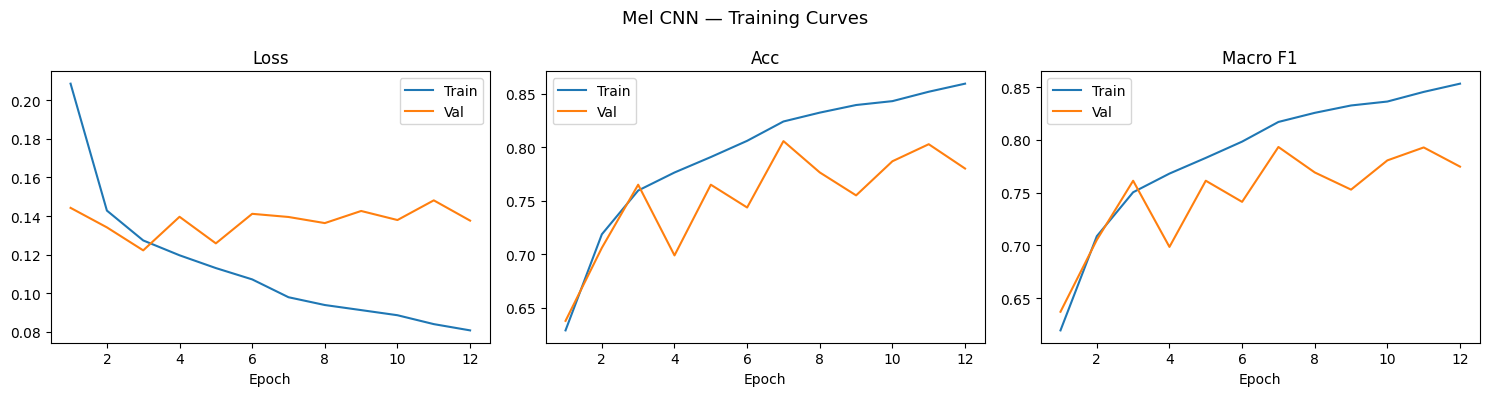

In [16]:
epochs = range(1, actual_epochs + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric in zip(axes, ['loss', 'acc', 'macro_f1']):
    ax.plot(epochs, history[f'train_{metric}'], label='Train')
    ax.plot(epochs, history[f'val_{metric}'],   label='Val')
    ax.set_title(metric.replace('_', ' ').title())
    ax.set_xlabel('Epoch')
    ax.legend()

plt.suptitle('Mel CNN \u2014 Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Evaluation

### 8.1 Overall test metrics and confusion matrix

Loads the best-by-val-F1 checkpoint and reports both class-weighted (matches the training objective) and unweighted (clean comparison number) test loss.

In [17]:
# Load best checkpoint from disk (single source of truth).
# weights_only=False is safe here since we saved this checkpoint ourselves.
ckpt = torch.load(BEST_CHECKPOINT_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

# Focal loss matches the training objective; unweighted CE is the clean
# comparison number against earlier runs and against any unweighted baseline.
test_loss, test_acc, test_f1 = validate_one_epoch(model, test_loader, criterion, device)

unweighted_criterion = nn.CrossEntropyLoss()
test_loss_unweighted, _, _ = validate_one_epoch(model, test_loader, unweighted_criterion, device)

print('=== Test Results ===')
print(f'Loss (focal, training objective): {test_loss:.4f}')
print(f'Loss (unweighted CE)            : {test_loss_unweighted:.4f}')
print(f'Accuracy                        : {test_acc:.4f}')
print(f'Macro F1                        : {test_f1:.4f}')

=== Test Results ===
Loss (focal, training objective): 0.1695
Loss (unweighted CE)            : 0.4558
Accuracy                        : 0.8038
Macro F1                        : 0.7766


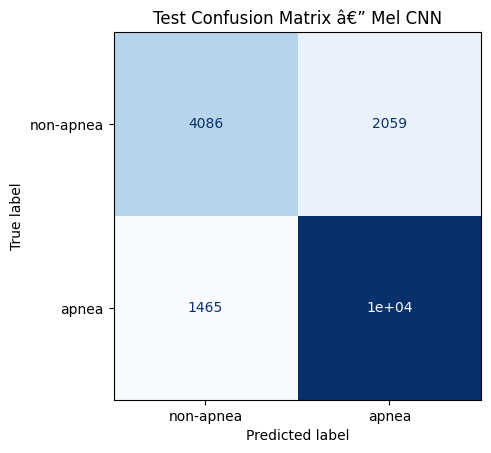

              precision    recall  f1-score   support

   non-apnea       0.74      0.66      0.70      6145
       apnea       0.83      0.88      0.85     11813

    accuracy                           0.80     17958
   macro avg       0.79      0.77      0.78     17958
weighted avg       0.80      0.80      0.80     17958



In [18]:
# Confusion matrix
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        preds  = torch.argmax(model(inputs), dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Test Confusion Matrix â€” Mel CNN")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

report = classification_report(all_labels, all_preds, target_names=CLASS_NAMES, output_dict=True)
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

### 8.2 Per apnea-type recall

Evaluates only on apnea segments, broken down by clinical type (OSA / CSA / Mixed-Hypopnea / Other). Useful for spotting which apnea patterns the model handles well versus which it under-detects.

In [19]:
# Evaluate only on apnea segments, broken down by type
ap_test_df = test_df[test_df['label'] == 1].copy()
ap_dataset = MelSpectrogramDataset(ap_test_df, PRECOMPUTED_DIR)
ap_loader  = DataLoader(ap_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

preds_all, types_all = [], ap_test_df['apnea_type'].tolist()
with torch.no_grad():
    for inputs, _ in ap_loader:
        preds = torch.argmax(model(inputs.to(device)), dim=1)
        preds_all.extend(preds.cpu().numpy())

print('=== Per Apnea-Type Recall (correctly detected as apnea) ===')
for t, name in APNEA_TYPE_NAMES.items():
    if t == 0:
        continue
    idxs = [i for i, tp in enumerate(types_all) if tp == t]
    if not idxs:
        continue
    correct = sum(preds_all[i] == 1 for i in idxs)
    print(f'  Type {t} ({name}): {correct}/{len(idxs)} = {correct/len(idxs):.3f}')

=== Per Apnea-Type Recall (correctly detected as apnea) ===
  Type 1 (OSA): 1277/1861 = 0.686
  Type 2 (CSA): 1893/2021 = 0.937
  Type 3 (Mixed/Hypopnea): 6931/7649 = 0.906
  Type 4 (Other): 247/282 = 0.876


## 9. Save results

In [20]:
results = {
    'experiment'      : 'mel_cnn',
    'feature'         : 'mel_spectrogram',
    'model'           : 'ResNet18',
    'best_epoch'      : best_epoch,
    'best_val_acc'    : float(best_val_acc),
    'best_val_macro_f1': float(best_val_f1),
    'test_loss'       : float(test_loss),
    'test_loss_unweighted': float(test_loss_unweighted),
    'test_accuracy'   : float(test_acc),
    'test_macro_f1'   : float(test_f1),
    'classification_report': report,
    'config': {
        'sample_rate' : SAMPLE_RATE,
        'n_mels'      : N_MELS,
        'n_fft'       : N_FFT,
        'hop_length'  : HOP_LENGTH,
        'f_min'       : F_MIN,
        'f_max'       : F_MAX,
        'db_floor'    : -100.0,
        'db_ceil'     : 0.0,
        'batch_size'  : BATCH_SIZE,
        'num_epochs'  : NUM_EPOCHS,
        'learning_rate': LEARNING_RATE,
        'weight_decay': WEIGHT_DECAY,
        'dropout'     : DROPOUT,
        'loss'        : {'type': 'focal', 'gamma': FOCAL_GAMMA, 'alpha': class_weights.tolist()},
        'spec_aug'    : {'freq': FREQ_MASK_PARAM, 'time': TIME_MASK_PARAM, 'n_masks': N_SPEC_MASKS},
        'num_train'   : len(train_dataset),
        'num_val'     : len(val_dataset),
        'num_test'    : len(test_dataset),
    }
}

with open(RESULTS_DIR / 'mel_cnn_results.json', 'w') as f:
    json.dump(results, f, indent=2)

with open(RESULTS_DIR / 'train_history.json', 'w') as f:
    json.dump(history, f, indent=2)

print('Results saved to:', RESULTS_DIR)

Results saved to: C:\Users\arshi\Desktop\AIS\Sem-2\Intelligent Sensing Systems\Practise Module\Project\ApneaSense\experiments\artifacts\audio\feature_representation\mel_cnn\results


## 10. Findings

### Headline metrics

| Metric | Value |
|---|---|
| Test accuracy | **0.8038** |
| Test macro F1 | **0.7766** |
| Test loss (unweighted CE) | 0.4558 |
| Test loss (focal, training objective) | 0.1695 |
| Best val macro F1 | 0.7932 (epoch 7 of 12) |
| Best val accuracy | 0.8058 |
| Trainable parameters | 11,171,268 |

### Per apnea-type recall (test set, apnea segments only)

| Apnea sub-type | Recall | Test segments |
|---|---|---|
| Type 1 — OSA (Obstructive Sleep Apnea) | **0.686** | 1,861 |
| Type 2 — CSA (Central Sleep Apnea) | **0.937** | 2,021 |
| Type 3 — Mixed / Hypopnea | **0.906** | 7,649 |
| Type 4 — Other | **0.876** | 282 |

### Cross-backbone / cross-feature comparison (same data, splits, focal loss)

| Notebook | Feature | Backbone | Pretraining | Test F1 | Test Acc | OSA recall |
|---|---|---|---|---|---|---|
| **`mel_cnn.ipynb` (this)** | **Log-Mel (n_mels=128)** | **ResNet18** | **ImageNet** | **0.7766** | **0.8038** | **0.686** |
| [`mel_pann.ipynb`](../Mel/mel_pann.ipynb) | Log-Mel (PANN internal, n_mels=64) | PANN Cnn14 | AudioSet | 0.7535 | 0.7693 | 0.567 |
| [`mfcc_cnn.ipynb`](../MFCC/mfcc_cnn.ipynb) | MFCC (n_mfcc=40) | ResNet18 | ImageNet | 0.7127 | 0.7491 | 0.559 |
| [`mel_ast.ipynb`](../Mel/mel_ast.ipynb) | Log-Mel (AST internal) | AST transformer | AudioSet | (abandoned — hardware) | — | — |
| [`raw_waveform_1dcnn.ipynb`](../Raw_waveform_1dcnn/raw_waveform_1dcnn.ipynb) | Raw waveform | 1D CNN | none | 0.6288 | 0.6662 | 0.531 |

The headline ranking — **Log-Mel + ResNet18 > Log-Mel + PANN ≈ MFCC + ResNet18 > Raw waveform + 1D CNN** — establishes two takeaways:
1. **Feature design > pretraining domain match.** A well-tuned ImageNet-pretrained CNN on 128-mel spectrograms beats an AudioSet-pretrained CNN that's locked into a 64-mel front-end.
2. **DCT compression hurts subtle classes.** MFCC and PANN end up with similar headline F1 (0.71 vs 0.75) and similar OSA recall (~0.56), but for different reasons: PANN coarser mel resolution, MFCC discarded high-order DCT coefficients. Both lose signal in the same places.

### Version history — how this notebook reached v4

The final v4 result emerged from four iterations of methodology fixes. Each version is documented for traceability:

| Version | Key changes | Test F1 | OSA recall | Notes |
|---|---|---|---|---|
| v1 | Initial: random subject split, per-sample max-abs norm, weighted CE loss | 0.7377 | 0.668 | Baseline; val drift due to non-stratified split |
| v2 | Stratified split, n_mels=64, f_max=2000, BatchNorm input, fixed dB-window norm, stronger SpecAugment | 0.7128 ↓ | **0.363** ↓ | OSA collapsed — f_max=2000 cut crucial high-frequency cues |
| v3 | Restored f_max=8000; softer SpecAugment | 0.7493 | 0.584 | Most of the OSA loss recovered; methodology now sound |
| **v4** | **n_mels=128**, **freq_mask=32**, **focal loss** | **0.7766** | **0.686** | Headline result — OSA back above v1, overall metrics best |

### Observations and design rationale

**Focal loss was the single biggest win in v4.** v3 used class-weighted CE; v4 swapped in focal loss (γ=2.0, same α). The biggest gains weren't on the rare class (which class-weighting already handled) — they were on the **hard-but-common** classes. Per-apnea-type recalls jumped:
- CSA recall: 0.849 → **0.937** (+9 pp)
- Mixed/Hypopnea recall: 0.810 → **0.906** (+10 pp)
- Other recall: 0.748 → **0.876** (+13 pp)
- OSA recall: 0.584 → **0.686** (+10 pp)

The `(1 − pₜ)^γ` term told the model to stop coasting on easy non-apnea predictions and refocus on the still-imperfect apnea sub-types. Test loss (unweighted CE) dropped from 0.566 → **0.456**, indicating better-calibrated predictions — not just better classifications.

**The `f_max` lesson (v2 → v3).** The PSG-Audio EDA showed 99.5% of bulk RMS energy lives below 100 Hz. v2 took that literally and capped the mel filterbank at f_max=2000, losing access to higher-frequency OSA-discriminative cues (snoring, restricted-airflow whistling). OSA recall **collapsed from 0.668 to 0.363** — a near-halving — while overall accuracy dropped only modestly. Restoring f_max=8000 (v3, v4) recovered most of it. *Bulk energy distribution and discriminative-feature distribution are not the same thing, and the EDA should not be over-trusted as a feature selection guide.*

**Stratified split kept the metrics honest.** v1's random subject-wise split drifted the apnea ratio across train/val/test (61.1% / 67.2% / 64.8% vs the dataset-wide 62.6%). v3's quartile-stratified split (kept in v4) holds the apnea ratio within ~1 pp of the overall mean. This makes class-weighted/focal-loss training stable and val/test losses directly comparable.

**OSA is structurally the hardest class.** Even at v4, OSA recall (0.686) trails the other apnea types (CSA 0.937, Mixed 0.906, Other 0.876). This is acoustically intuitive: OSA episodes involve *partial* airway obstruction with continued breathing effort — the audio difference from normal breathing is subtle (snoring, reduced airflow). CSA episodes are acoustically obvious (silence — patient stops breathing); OSA is not. The same OSA-difficulty pattern shows up across **every** backbone in this project — a structural property of the task, not of the model.

**Train/val gap is well-controlled.** At the best epoch, train F1 ≈ 0.82 vs val F1 ≈ 0.79 — a 3 pp gap. Dropout 0.6 in the head, SpecAugment on every batch, and weight decay 1e-3 collectively kept the gap from widening into outright overfitting. Focal loss likely also acts as mild implicit regularization by not over-confidently fitting the easy examples.

### Limitations

- **ResNet18 is image-pretrained, not audio-pretrained.** A model that already knows what spectrograms look like would have a more domain-relevant prior. We tested this hypothesis with [`mel_pann.ipynb`](../Mel/mel_pann.ipynb) (PANN Cnn14 / AudioSet); it underperformed v4 here, likely because Cnn14's 64-mel pretraining and our task-specific 128-mel fine-tune had a feature-distribution mismatch.
- **Fixed 10-second window.** Real apnea events span 10–30+ seconds; a single 10s segment may catch the middle but miss the lead-up breathing change or the recovery breath at the end.
- **Single channel.** PSG setups can capture multiple microphones; this experiment uses just one.
- **Segment-level metrics only.** We report per-segment F1/accuracy. A clinical deployment would care about per-patient AHI estimation accuracy, which requires aggregating segment predictions back into events. Not done here.
- **No subject-level cross-validation.** The 70/15/15 split with a single seed is pragmatic but a 5-fold subject CV would give tighter confidence intervals on the headline numbers.

### What this experiment establishes

A well-tuned ImageNet-pretrained ResNet18 on carefully-designed Mel spectrograms reaches **F1 ≈ 0.78 / Accuracy ≈ 0.80** on a held-out subject-stratified test set, with OSA recall 0.69 and CSA/Mixed recall above 0.90. This is the strongest result among the four feature/backbone experiments in this project, beating an audio-pretrained CNN (PANN Cnn14, F1 0.75), a classical MFCC-based variant (F1 0.71), and a from-scratch raw-waveform 1D CNN (F1 0.63), and outperforming an AudioSet-pretrained transformer (AST) by virtue of actually fitting on the available hardware.